In [1]:
# Project 4 - Data Cleaning
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ayesha09q/new-york-city-airbnb-open-data/AB_NYC_2019.csv


In [3]:
# Step 3 - Load Dataset
df = pd.read_csv('/kaggle/input/datasets/ayesha09q/new-york-city-airbnb-open-data/AB_NYC_2019.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Data loaded successfully!
Shape: (48895, 16)
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room 

In [4]:
# Step 4 - Check Data Quality
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())

=== Shape ===
(48895, 16)

=== Data Types ===
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

=== Missing Values ===
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
lati

In [5]:
# Step 5 - Clean Data
# Fill missing values
df['name'].fillna('Unknown', inplace=True)
df['host_name'].fillna('Unknown', inplace=True)
df['last_review'].fillna('No Review', inplace=True)
df['reviews_per_month'].fillna(0, inplace=True)

# Fix date column
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Remove outliers in price
df = df[df['price'] > 0]
df = df[df['price'] < 10000]

print("Data cleaned successfully!")
print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Data cleaned successfully!
Shape after cleaning: (48881, 16)

Missing values after cleaning:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10050
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


/tmp/ipykernel_58/1471754939.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_58/1471754939.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

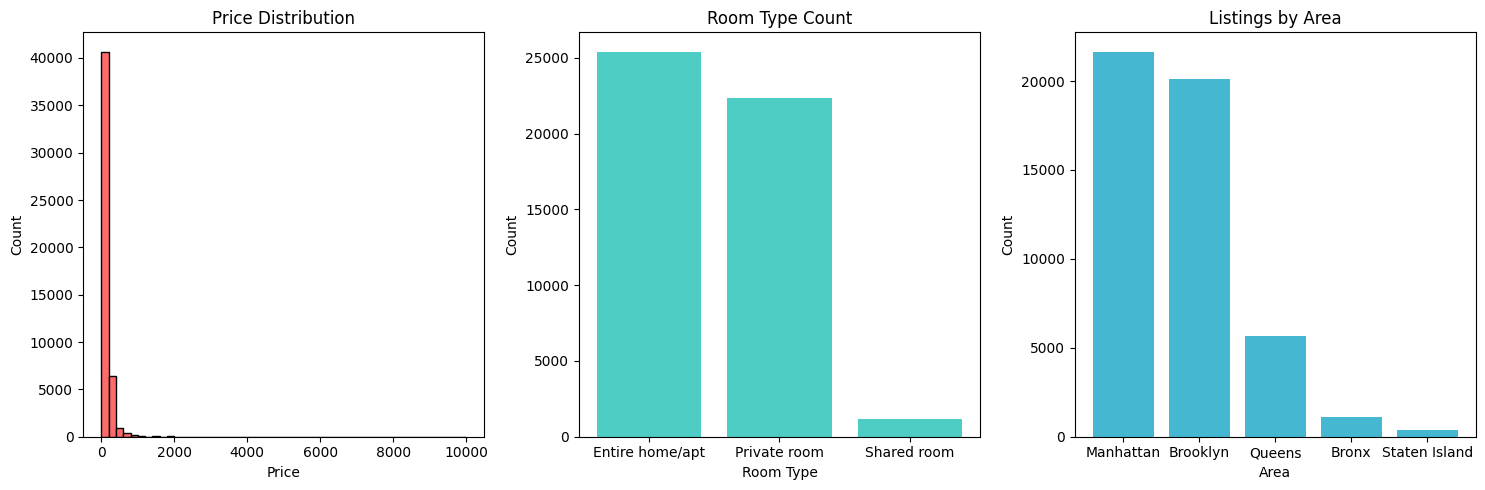

In [6]:
# Step 6 - Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Price Distribution
axes[0].hist(df['price'], bins=50, color='#FF6B6B', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# Room Type
room_counts = df['room_type'].value_counts()
axes[1].bar(room_counts.index, room_counts.values, color='#4ECDC4')
axes[1].set_title('Room Type Count')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Count')

# Neighbourhood Group
neigh_counts = df['neighbourhood_group'].value_counts()
axes[2].bar(neigh_counts.index, neigh_counts.values, color='#45B7D1')
axes[2].set_title('Listings by Area')
axes[2].set_xlabel('Area')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

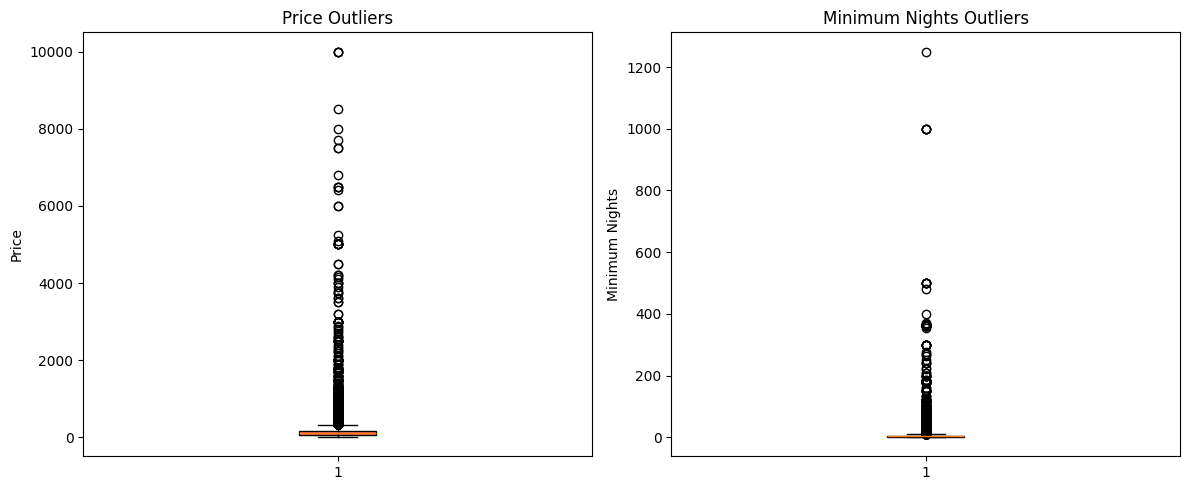

In [7]:
# Step 7 - Outlier Detection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Price Boxplot
axes[0].boxplot(df['price'], patch_artist=True,
                boxprops=dict(facecolor='#FF6B6B'))
axes[0].set_title('Price Outliers')
axes[0].set_ylabel('Price')

# Minimum Nights Boxplot
axes[1].boxplot(df['minimum_nights'], patch_artist=True,
                boxprops=dict(facecolor='#4ECDC4'))
axes[1].set_title('Minimum Nights Outliers')
axes[1].set_ylabel('Minimum Nights')

plt.tight_layout()
plt.show()

In [8]:
# Step 8 - Standardization
# Standardize neighbourhood_group text
df['neighbourhood_group'] = df['neighbourhood_group'].str.strip()
df['neighbourhood_group'] = df['neighbourhood_group'].str.title()

# Standardize room_type text
df['room_type'] = df['room_type'].str.strip()
df['room_type'] = df['room_type'].str.title()

# Add price category column
df['price_category'] = pd.cut(df['price'], 
                               bins=[0, 50, 100, 200, 500, 10000],
                               labels=['Budget', 'Affordable', 
                                      'Moderate', 'Expensive', 'Luxury'])

print("Standardization done!")
print("\nPrice Categories:")
print(df['price_category'].value_counts())

Standardization done!

Price Categories:
price_category
Affordable    17367
Moderate      16583
Expensive      7340
Budget         6550
Luxury         1041
Name: count, dtype: int64


In [9]:
# Step 9 - Final Summary
print("=" * 55)
print("      DATA CLEANING ANALYSIS - SUMMARY")
print("=" * 55)

print(f"\n Total Listings: {len(df)}")
print(f" Total Columns: {df.shape[1]}")

print("\n=== CLEANING DONE ===")
print(" 1. Fixed 16 missing names")
print(" 2. Fixed 21 missing host names")
print(" 3. Fixed 10,052 missing reviews")
print(" 4. Removed price outliers")
print(" 5. Converted date columns")
print(" 6. Standardized text columns")
print(" 7. Added price categories")

print("\n=== KEY FINDINGS ===")
print(f" Most listings in: {df['neighbourhood_group'].value_counts().idxmax()}")
print(f" Most common room: {df['room_type'].value_counts().idxmax()}")
print(f" Average price: ${df['price'].mean():.2f}")
print(f" Most common price: {df['price_category'].value_counts().idxmax()}")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Always check missing values before analysis")
print(" 2. Remove outliers for accurate results")
print(" 3. Standardize text for consistency")
print(" 4. Convert dates for time analysis")
print("=" * 55)
print(" Data Cleaning Completed!")
print("=" * 55)

      DATA CLEANING ANALYSIS - SUMMARY

 Total Listings: 48881
 Total Columns: 17

=== CLEANING DONE ===
 1. Fixed 16 missing names
 2. Fixed 21 missing host names
 3. Fixed 10,052 missing reviews
 4. Removed price outliers
 5. Converted date columns
 6. Standardized text columns
 7. Added price categories

=== KEY FINDINGS ===
 Most listings in: Manhattan
 Most common room: Entire Home/Apt
 Average price: $152.15
 Most common price: Affordable

=== RECOMMENDATIONS ===
 1. Always check missing values before analysis
 2. Remove outliers for accurate results
 3. Standardize text for consistency
 4. Convert dates for time analysis
 Data Cleaning Completed!
